In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [2]:

data = './BTC-market-analysis_2021-25.csv'
df = pd.read_csv(data)
df = df[["date", "btc_return", "sp500_return", "gold_return"]]

In [3]:
df['date'] = pd.to_datetime(df['date'])
df['date2'] = df['date']

In [4]:
df.set_index('date2', inplace=True)

In [5]:
df = df.loc['2022':]

In [6]:

df = df.replace(0.000000, pd.NA)
df = df.dropna(subset=["sp500_return"])        
df = df.dropna(subset=["gold_return"])  


In [7]:
df["date"]

date2
2022-01-03   2022-01-03
2022-01-04   2022-01-04
2022-01-05   2022-01-05
2022-01-06   2022-01-06
2022-01-07   2022-01-07
                ...    
2026-01-05   2026-01-05
2026-01-06   2026-01-06
2026-01-07   2026-01-07
2026-01-08   2026-01-08
2026-01-09   2026-01-09
Name: date, Length: 1008, dtype: datetime64[us]

In [8]:
size = len(df)
btc_bal = np.empty(size)
sp500_bal = np.empty(size)
gold_bal = np.empty(size)
invested = np.empty(size) 

btc_return = df["btc_return"].values
sp500_return = df["sp500_return"].values
gold_return = df["gold_return"].values

for i in range(size):  
    if i == 0:
        btc_bal[0] = 100
        sp500_bal[0] = 100
        gold_bal[0] = 100      
        invested[0] = 100
        continue
    elif i % 14 == 0:
        btc_bal[i] = btc_bal[i-1] * (1 + btc_return[i-1]) + 100
        sp500_bal[i] = sp500_bal[i-1] * (1 + sp500_return[i-1]) + 100
        gold_bal[i] = gold_bal[i-1] * (1 + gold_return[i-1]) + 100
    else:
        btc_bal[i] = btc_bal[i-1] * (1 + btc_return[i-1])
        sp500_bal[i] = sp500_bal[i-1] * (1 + sp500_return[i-1])
        gold_bal[i] = gold_bal[i-1] * (1 + gold_return[i-1])
    invested[i] = (1 + i // 14) * 100

In [9]:
### TEST 

df["BTC Balance"] = 0.00000

df["SP500 Balance"] = 0.00000

df["Gold Balance"] = 0.00000

df["Invested Balance"] = 0.00000

size = len(df)
for i in range(size):  
    if i == 0:
        df.iloc[i,4] = 100
        df.iloc[i,5] = 100
        df.iloc[i,6] = 100      
        df.iloc[i,7] = 100
    elif i % 14 == 0:
        line = df.iloc[i-1]
        df.iloc[i,4] = line["BTC Balance"] * (1 + line["btc_return"]) + 100
        df.iloc[i,5] = line["SP500 Balance"] * (1 + line["sp500_return"]) + 100
        df.iloc[i,6] = line["Gold Balance"] * (1 + line["gold_return"]) + 100
        df.iloc[i,7] = df.iloc[i-1,7] + 100
    else:
        line = df.iloc[i-1]
        df.iloc[i,4] = line["BTC Balance"] * (1 + line["btc_return"])
        df.iloc[i,5] = line["SP500 Balance"] * (1 + line["sp500_return"])
        df.iloc[i,6] = line["Gold Balance"] * (1 + line["gold_return"])
        df.iloc[i,7] = df.iloc[i-1,7]   

date = np.array(df["date"])
BTC_Balance = np.array(df["BTC Balance"])
SP500_Balance = np.array(df["SP500 Balance"])
Gold_Balance = np.array(df["Gold Balance"])
Invested = np.array(df["Invested Balance"])

In [10]:
date = np.array(df["date"])

In [11]:
btc_bal

array([  100.        ,    98.12631225,    96.94236383, ...,
       12486.69222105, 12164.16686464, 12126.74107994], shape=(1008,))

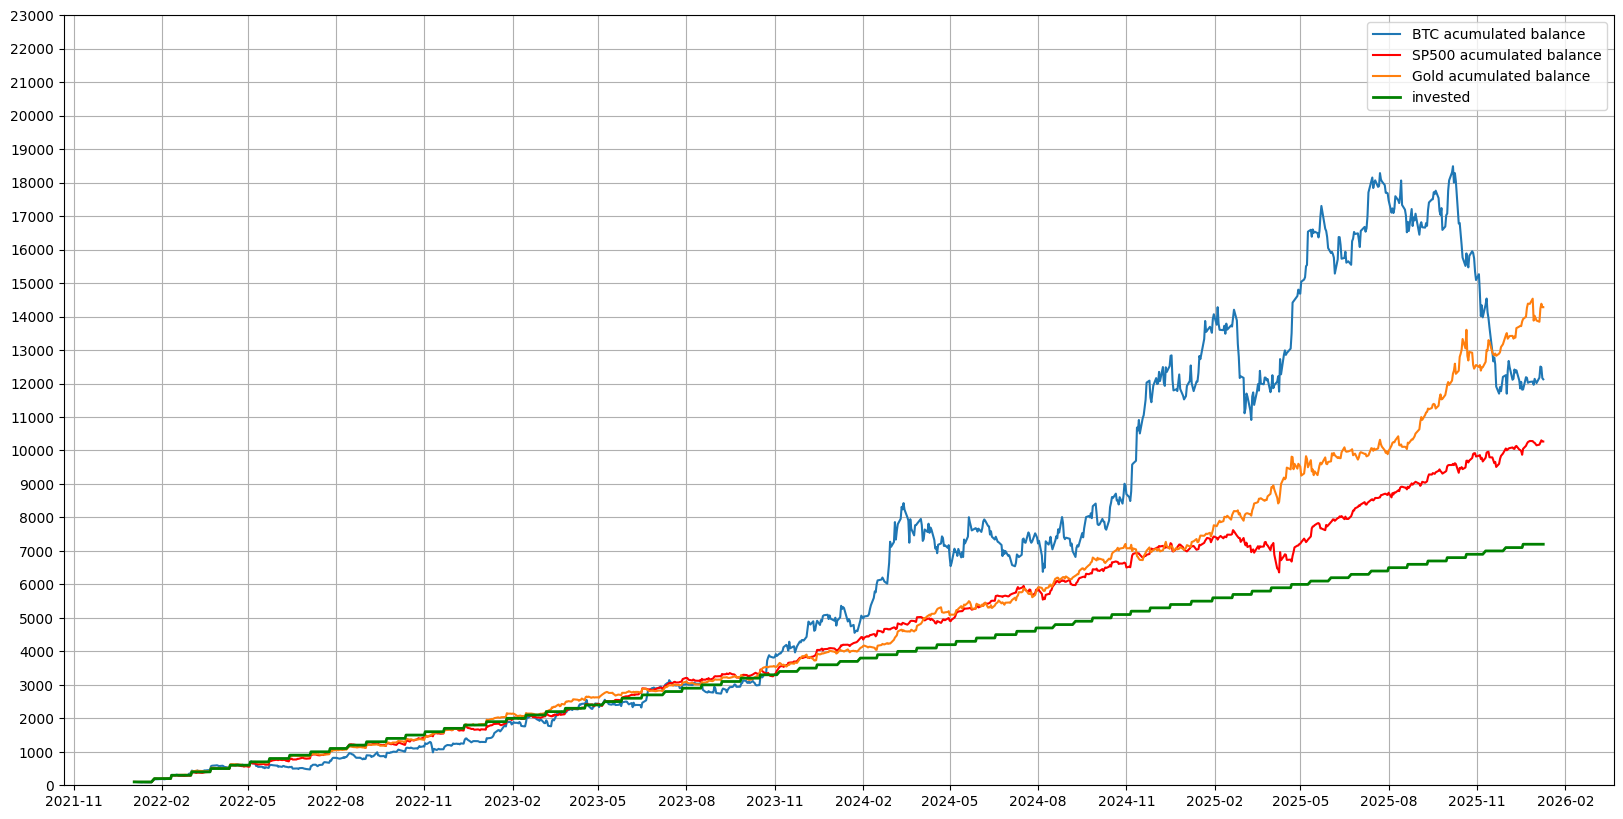

In [12]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(date, BTC_Balance, label='BTC acumulated balance')
ax.plot(date, SP500_Balance, label='SP500 acumulated balance', color = 'red')
ax.plot(date, Gold_Balance, label='Gold acumulated balance')
ax.plot(date, Invested, linewidth=2, label = 'invested', color = 'green')
ax.legend()
ax.yaxis.set_major_locator(ticker.MultipleLocator(1000))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.set_ylim(0, 23000) 
ax.grid(axis='y', label="Value (USD)")
ax.grid(axis='x')
plt.show()

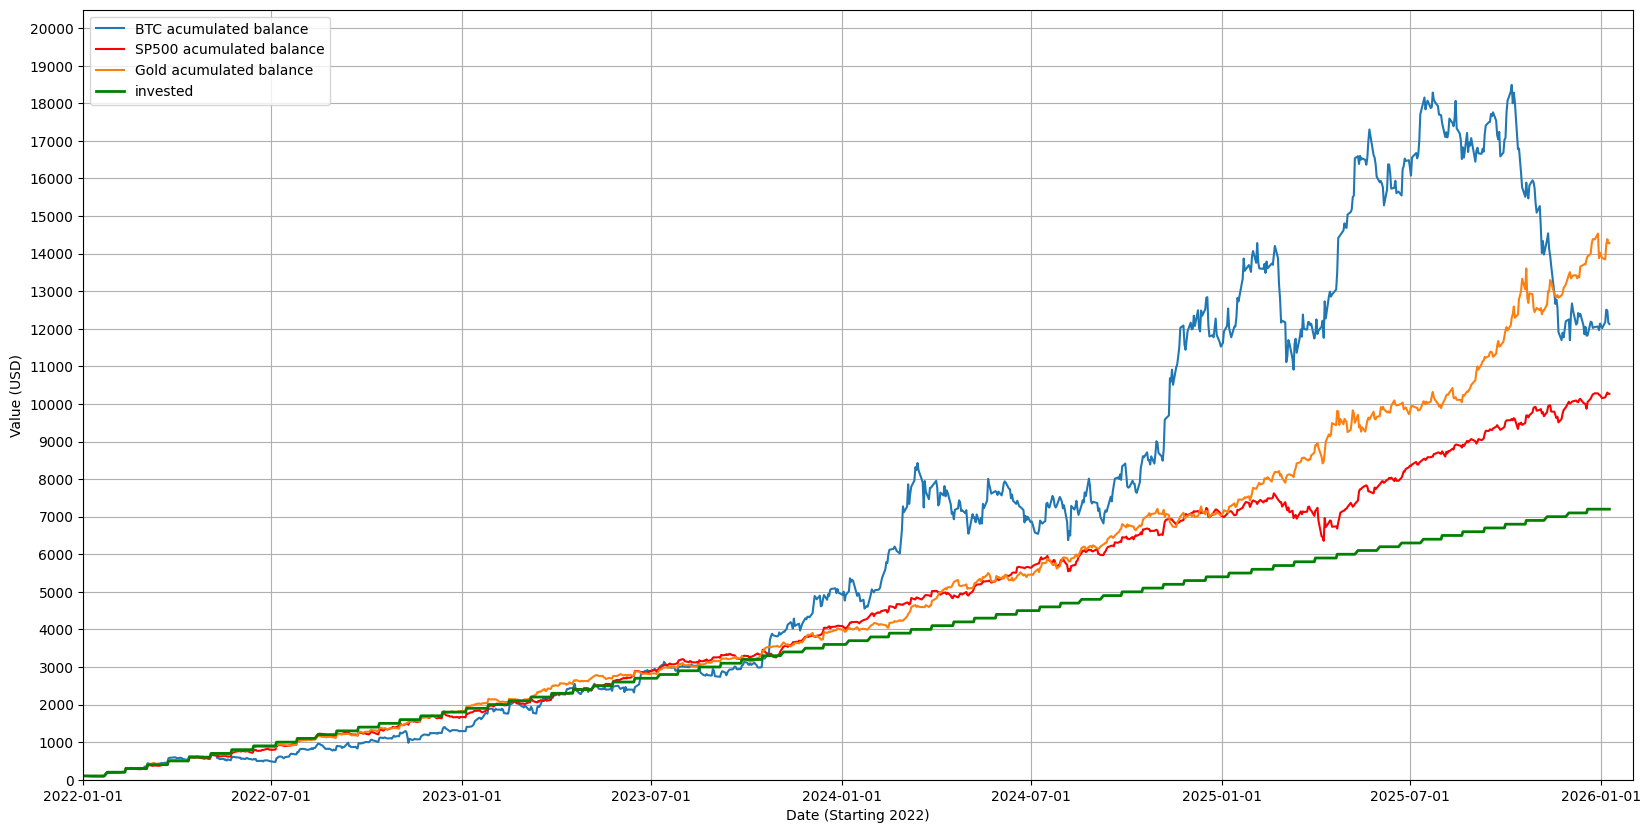

In [50]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(date, btc_bal, label='BTC acumulated balance')
ax.plot(date, sp500_bal, label='SP500 acumulated balance', color = 'red')
ax.plot(date, gold_bal, label='Gold acumulated balance')
ax.plot(date, invested, linewidth=2, label = 'invested', color = 'green')
ax.legend()
ax.yaxis.set_major_locator(ticker.MultipleLocator(1000))
# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlim(pd.to_datetime('2022-01-01'), pd.to_datetime('2026-02')) 
ax.set_ylim(0, 2000 + max([max(btc_bal), max(sp500_bal), max(gold_bal)]))
ax.set_ylabel("Value (USD)")
ax.set_xlabel("Date (Starting 2022)")
ax.grid(axis='y')
ax.grid(axis='x')
plt.show()